# Análise Exploratória — Classificação de Abstracts Médicos

Este notebook faz a análise exploratória do
[Medical Abstracts TC Corpus](https://www.kaggle.com/datasets/saharalaa/medical-abstracts-tc-corpus?resource=download),
a base que alimenta o classificador de textos médicos deste projeto.

O objetivo é responder três perguntas antes de qualquer modelagem:

1. **Os dados são o que dizem ser?** Estrutura, volume, qualidade e integridade.
2. **O que o texto revela?** Vocabulário, padrões por classe e implicações
   diretas para as escolhas de vetorização.
3. **O problema está bem formulado?** Se a tarefa foi enunciada como
   classificação multiclasse, os dados sustentam essa formulação?

A terceira pergunta é a mais importante deste notebook — e a resposta,
antecipada na seção 7, muda o entendimento do projeto inteiro.

> **Escopo.** Este notebook é exploratório e autocontido: todo o código
> necessário está aqui dentro, sem importar módulos de `src/`. A modelagem
> baseline e a avaliação de modelos ficam no notebook
> `02_baseline_modelagem.ipynb`, que consome as conclusões daqui.

## 1. Definição do problema

O corpus distribui uma linha por par `(abstract, condição)`, mas o mesmo abstract pode estar associado a várias condições. Portanto, a formulação adotada neste projeto é **classificação multilabel**: cada abstract pode receber uma ou mais das cinco categorias.

O objetivo continua sendo apoio à categorização de abstracts públicos em inglês, nunca diagnóstico clínico. A EDA também audita duplicação e separação entre treino e teste para impedir que o modelo veja no treino um texto reservado ao teste.

## 2. Bibliotecas

Imports organizados por finalidade. Este notebook não faz modelagem, então
não importa classificadores: apenas utilitários de amostragem estratificada e
vetorização usados para caracterizar o vocabulário.

In [1]:
# torch (opcional; usado só pelo baseline experimental de BERT em outro lugar
# do projeto) precisa carregar antes do pandas: no Windows, a DLL nativa do
# torch falha ao inicializar se o pandas reivindicar o caminho de busca de
# DLLs do processo primeiro.
try:
    import torch  # noqa: F401
except ImportError:
    pass

# Manipulação de dados
from collections import Counter
from html import escape
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd

# Visualização
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Processamento de texto
import nltk
from nltk.corpus import stopwords
import spacy
from unidecode import unidecode

# Utilitários de análise (amostragem estratificada e caracterização de vocabulário)
import sklearn
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

## 3. Configuração do notebook

Os caminhos são resolvidos a partir da raiz do projeto, de modo que o notebook
funcione tanto executado de `notebooks/` quanto da raiz do repositório.

In [2]:
RANDOM_STATE = 42
WORKING_SAMPLE_SIZE = 6000
TEXT_COLUMN = "medical_abstract"
TARGET_ID_COLUMN = "condition_label"
TARGET_COLUMN = "condition_name"
SPACY_MODEL = "en_core_web_sm"

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw").exists() and (PROJECT_ROOT.parent / "data" / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"
REPORT_PATH = REPORT_DIR / "eda_nlp_hospital.html"

REPORT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "medical_tc_train.csv"
TEST_PATH = DATA_DIR / "medical_tc_test.csv"
LABELS_PATH = DATA_DIR / "medical_tc_labels.csv"

print(f"Projeto: {PROJECT_ROOT}")
print(f"Dados: {DATA_DIR}")
print(f"Relatório HTML: {REPORT_PATH}")

Projeto: C:\Users\jayne_m2ck4ov\Documents\POS MLE\FASE 3\ml3-f3-tech-challenge
Dados: C:\Users\jayne_m2ck4ov\Documents\POS MLE\FASE 3\ml3-f3-tech-challenge\data\raw
Relatório HTML: C:\Users\jayne_m2ck4ov\Documents\POS MLE\FASE 3\ml3-f3-tech-challenge\reports\eda_nlp_hospital.html


## 4. Importação dos dados

O corpus é distribuído em três arquivos: treino oficial, teste oficial e a
tabela que mapeia o identificador numérico da condição para o nome legível.

Consolidamos treino e teste num único `DataFrame` para a análise exploratória,
preservando a origem de cada linha na coluna `source_split`. Essa coluna será
essencial na seção 7 e na verificação de drift entre os splits oficiais.

In [3]:
required_files = [TRAIN_PATH, TEST_PATH, LABELS_PATH]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Arquivos esperados não encontrados: "
        + ", ".join(str(path) for path in missing_files)
        + ". Baixe o dataset do Kaggle e mantenha os CSVs em data/raw."
    )

train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)
labels = pd.read_csv(LABELS_PATH)

df = pd.concat(
    [
        train_raw.assign(source_split="kaggle_train"),
        test_raw.assign(source_split="kaggle_test"),
    ],
    ignore_index=True,
)
df = df.merge(labels, on=TARGET_ID_COLUMN, how="left")

display(df.head())
print(f"Shape treino Kaggle: {train_raw.shape}")
print(f"Shape teste Kaggle: {test_raw.shape}")
print(f"Shape consolidado: {df.shape}")
print(f"Colunas disponíveis: {list(df.columns)}")
print(f"Coluna de texto: {TEXT_COLUMN}")
print(f"Coluna alvo: {TARGET_COLUMN}")

,condition_label,medical_abstract,source_split,condition_name
0,5,Tissue changes around loose prostheses. A canine model to investigate the effects of an antiinflammatory agent. The ...,kaggle_train,general pathological conditions
1,1,Neuropeptide Y and neuron-specific enolase levels in benign and malignant pheochromocytomas. Neuron-specific enolase...,kaggle_train,neoplasms
2,2,"Sexually transmitted diseases of the colon, rectum, and anus. The challenge of the nineties. During the past two dec...",kaggle_train,digestive system diseases
3,1,Lipolytic factors associated with murine and human cancer cachexia. We have identified a lipolytic factor in extract...,kaggle_train,neoplasms
4,3,"Does carotid restenosis predict an increased risk of late symptoms, stroke, or death? The identification of carotid ...",kaggle_train,nervous system diseases


Shape treino Kaggle: (11550, 2)
Shape teste Kaggle: (2888, 2)
Shape consolidado: (14438, 4)
Colunas disponíveis: ['condition_label', 'medical_abstract', 'source_split', 'condition_name']
Coluna de texto: medical_abstract
Coluna alvo: condition_name


## 5. Entendimento inicial da base

Primeiro retrato dos dados: volume, classes, distribuição e tamanho dos textos.
Os exemplos são truncados propositalmente — mesmo sendo abstracts públicos, a
prática de não despejar texto clínico completo no output do notebook é o
comportamento correto a carregar para um cenário com dados reais.

In [4]:
df["text_original"] = df[TEXT_COLUMN].astype("string").fillna("")
df["text_length_chars"] = df["text_original"].str.len()
df["text_length_words"] = df["text_original"].str.split().str.len()

class_distribution = (
    df[TARGET_COLUMN]
    .value_counts(dropna=False)
    .rename_axis("classe")
    .reset_index(name="registros")
)
class_distribution["proporcao"] = class_distribution["registros"] / len(df)

print(f"Quantidade de registros: {len(df):,}")
print(f"Quantidade de classes: {df[TARGET_COLUMN].nunique(dropna=True)}")
display(class_distribution)
display(df[["text_length_chars", "text_length_words"]].describe().round(2))

safe_examples = (
    df.sample(min(5, len(df)), random_state=RANDOM_STATE)
    [[TARGET_COLUMN, "text_original"]]
    .assign(text_original=lambda data: data["text_original"].str.slice(0, 260) + "...")
)
display(safe_examples)

Quantidade de registros: 14,438
Quantidade de classes: 5


,classe,registros,proporcao
0,general pathological conditions,4805,0.332802
1,neoplasms,3163,0.219075
2,cardiovascular diseases,3051,0.211317
3,nervous system diseases,1925,0.133329
4,digestive system diseases,1494,0.103477


,text_length_chars,text_length_words
count,14438.0,14438.00
mean,1230.67,179.94
std,507.35,76.55
min,170.0,24.00
25%,850.0,122.00
50%,1210.0,176.00
75%,1589.0,235.00
max,3999.0,596.00


,condition_name,text_original
4417,cardiovascular diseases,A manifesting carrier of Duchenne muscular dystrophy with severe myocardial symptoms. A 42-year-old so-called manife...
907,cardiovascular diseases,Transesophageal Doppler color flow mapping assessment of atrial septal defect. Transesophageal Doppler color flow im...
2859,cardiovascular diseases,Outcomes of direct coronary angioplasty for acute myocardial infarction in candidates and non-candidates for thrombo...
5836,cardiovascular diseases,Salvage from cardiogenic shock by atherectomy after failed emergency coronary artery angioplasty. In this case repor...
2715,neoplasms,Leukaemia complicating treatment for Hodgkin's disease: the experience of the British National Lymphoma Investigatio...


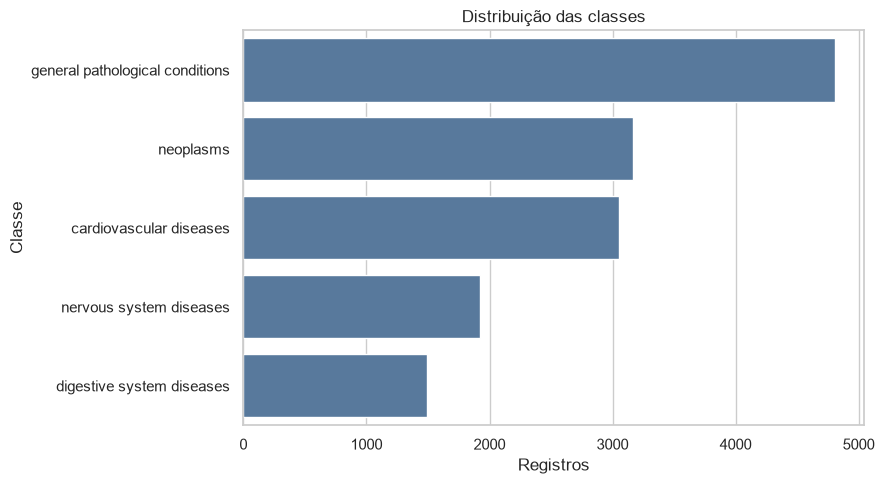

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=class_distribution, x="registros", y="classe", ax=ax, color="#4C78A8")
ax.set_title("Distribuição das classes")
ax.set_xlabel("Registros")
ax.set_ylabel("Classe")
plt.tight_layout()
class_plot_path = FIGURE_DIR / "class_distribution.png"
fig.savefig(class_plot_path, dpi=140, bbox_inches="tight")
plt.show()

**Leitura.** O desbalanceamento é moderado, não severo: a maior classe
(`general pathological conditions`, ~33%) tem cerca de três vezes o volume da
menor (`digestive system diseases`, ~10%). É o suficiente para justificar
`class_weight="balanced"` e para exigir macro-F1 em vez de acurácia, mas não
chega ao ponto de precisar de reamostragem agressiva.

Os textos são longos e homogêneos: mediana em torno de 175 palavras, cauda até
~600. Isso tem duas consequências práticas: há sinal lexical suficiente por
documento (bom para TF-IDF) e, se um dia entrar um transformer, será preciso
`max_length=512` para não truncar boa parte do conteúdo.

## 6. Sanity check

Esta seção apenas **diagnostica**; nenhum tratamento é aplicado aqui. O objetivo
é listar de forma estruturada tudo que precisa de decisão consciente depois.

In [6]:
sanity_report = pd.DataFrame(
    {
        "checagem": [
            "linhas",
            "colunas",
            "textos nulos",
            "alvos nulos",
            "textos vazios",
            "textos muito curtos (< 20 caracteres)",
            "duplicidades totais (linha inteira)",
            "duplicidades por texto",
            "duplicidades por texto e classe",
            "classes sem nome após o merge",
        ],
        "valor": [
            len(df),
            df.shape[1],
            int(df[TEXT_COLUMN].isna().sum()),
            int(df[TARGET_COLUMN].isna().sum()),
            int(df["text_original"].str.strip().eq("").sum()),
            int(df["text_length_chars"].lt(20).sum()),
            int(df.duplicated().sum()),
            int(df.duplicated(subset=["text_original"]).sum()),
            int(df.duplicated(subset=["text_original", TARGET_COLUMN]).sum()),
            int(df[TARGET_COLUMN].isna().sum()),
        ],
    }
)
display(sanity_report)

print("Observação: esta seção apenas diagnostica problemas; nenhum tratamento é aplicado aqui.")

,checagem,valor
0,linhas,14438
1,colunas,7
2,textos nulos,0
3,alvos nulos,0
4,textos vazios,0
5,textos muito curtos (< 20 caracteres),0
6,duplicidades totais (linha inteira),0
7,duplicidades por texto,3211
8,duplicidades por texto e classe,0
9,classes sem nome após o merge,0


Observação: esta seção apenas diagnostica problemas; nenhum tratamento é aplicado aqui.


**Leitura — e o fio da meada.** A base está limpa no que costuma dar problema:
nenhum texto nulo, nenhum alvo nulo, nenhum texto vazio, nenhuma classe órfã
após o merge.

Mas duas linhas dessa tabela não fecham entre si:

- **duplicidades por texto**: milhares;
- **duplicidades por texto e classe**: **zero**.

Isso é estranho. Se houvesse simplesmente registros repetidos por erro de
coleta, os dois números seriam parecidos. O fato de o segundo ser exatamente
zero significa que **todo texto repetido aparece com uma classe diferente** —
nunca com a mesma. Isso não é sujeira; é estrutura. A próxima seção investiga.

## 7. O achado que muda o problema: o corpus é multirrótulo achatado

A anomalia do sanity check tem uma explicação única e consistente.

**O Medical Abstracts TC Corpus é, na origem, um dataset multirrótulo.** Um
mesmo abstract pode discutir mais de uma condição médica. Ao ser distribuído em
formato tabular, ele foi *achatado*: uma linha por par (abstract, condição).
Quando um texto se qualifica para duas condições, ele aparece duas vezes no
CSV — uma por rótulo, nunca com o rótulo repetido.

Um classificador multiclasse é obrigado a escolher **um** rótulo. Mas o gabarito
pode cobrar **qualquer um** dos rótulos válidos daquele abstract, e não
necessariamente o mesmo que apareceu no treino.

As subseções a seguir medem o tamanho desse efeito e o seu custo em métrica.

### 7.1 Quantos abstracts têm mais de um rótulo?

In [7]:
label_sets_by_text = df.groupby(TEXT_COLUMN)[TARGET_COLUMN].agg(set)
n_labels_per_text = label_sets_by_text.apply(len)

multilabel_summary = (
    n_labels_per_text.value_counts()
    .sort_index()
    .rename_axis("rotulos_distintos_por_abstract")
    .reset_index(name="abstracts")
)
multilabel_summary["percentual"] = (
    multilabel_summary["abstracts"] / len(label_sets_by_text) * 100
).round(1)

duplicated_text_label_pairs = int(df.duplicated(subset=[TEXT_COLUMN, TARGET_COLUMN]).sum())
multilabel_share = float((n_labels_per_text > 1).mean())

print(f"Linhas totais no corpus consolidado: {len(df):,}")
print(f"Abstracts (textos) únicos: {len(label_sets_by_text):,}")
print(f"Pares (texto, rótulo) duplicados: {duplicated_text_label_pairs}")
print("   ^ zero confirma que cada linha extra é um rótulo ADICIONAL, não uma duplicata de coleta.")
print()
print("Distribuição de rótulos distintos por abstract único:")
display(multilabel_summary)
print(f"\n{multilabel_share:.1%} dos abstracts únicos têm mais de um rótulo válido no corpus.")

Linhas totais no corpus consolidado: 14,438
Abstracts (textos) únicos: 11,227
Pares (texto, rótulo) duplicados: 0
   ^ zero confirma que cada linha extra é um rótulo ADICIONAL, não uma duplicata de coleta.

Distribuição de rótulos distintos por abstract único:


,rotulos_distintos_por_abstract,abstracts,percentual
0,1,8298,73.9
1,2,2653,23.6
2,3,270,2.4
3,4,6,0.1



26.1% dos abstracts únicos têm mais de um rótulo válido no corpus.


**Leitura.** Cerca de **1 em cada 4 abstracts** (~26%) carrega de 2 a 4 rótulos
igualmente válidos. A assinatura — texto repetido, par (texto, rótulo) nunca
repetido — é exatamente a de uma tabela multirrótulo normalizada em formato
longo.

O exemplo abaixo é buscado dinamicamente nos dados, para que continue verdadeiro
se a base for atualizada.

In [8]:
candidates = n_labels_per_text[n_labels_per_text == 3]
example_text = candidates.index[0] if len(candidates) else n_labels_per_text.idxmax()
example_labels = sorted(label_sets_by_text[example_text])

print("O MESMO abstract aparece no corpus com um rótulo diferente em cada linha:\n")
print(example_text[:280] + ("..." if len(example_text) > 280 else ""))
print("\nRótulos atribuídos a este abstract:")
for label in example_labels:
    print(f"  - {label}")

O MESMO abstract aparece no corpus com um rótulo diferente em cada linha:

'Locked-in syndrome' for 27 years following a viral illness: clinical and pathologic findings. We describe a man who, after a presumed encephalitic illness, was "locked-in" for 27 years. His CT and autopsy findings showed atrophy of the brainstem and a cystic lesion at the base o...

Rótulos atribuídos a este abstract:
  - general pathological conditions
  - neoplasms
  - nervous system diseases


### 7.2 `general pathological conditions` não é uma classe disjunta

Se o multirrótulo fosse distribuído por igual entre as classes, o efeito seria
homogêneo. Não é o caso — e a classe majoritária é justamente a mais afetada.

In [9]:
pair_counts = Counter()
for label_set in label_sets_by_text[n_labels_per_text > 1]:
    ordered = sorted(label_set)
    for i, first in enumerate(ordered):
        for second in ordered[i + 1:]:
            pair_counts[(first, second)] += 1

cooccurrence_df = (
    pd.DataFrame(
        [(a, b, n) for (a, b), n in pair_counts.items()],
        columns=["rotulo_a", "rotulo_b", "abstracts_em_comum"],
    )
    .sort_values("abstracts_em_comum", ascending=False)
    .reset_index(drop=True)
)
print("Pares de rótulos que mais co-ocorrem no mesmo abstract:")
display(cooccurrence_df.head(10))

rows = []
for label in class_distribution["classe"]:
    texts_with_label = label_sets_by_text[label_sets_by_text.apply(lambda labels: label in labels)]
    multi_fraction = float(texts_with_label.apply(len).gt(1).mean())
    rows.append({
        "classe": label,
        "abstracts": len(texts_with_label),
        "pct_tambem_com_outro_rotulo": round(multi_fraction * 100, 1),
    })

per_label_multilabel = (
    pd.DataFrame(rows)
    .sort_values("pct_tambem_com_outro_rotulo", ascending=False)
    .reset_index(drop=True)
)
print("\nPor classe: quantos abstracts, e que fração deles também leva outro rótulo:")
display(per_label_multilabel)

Pares de rótulos que mais co-ocorrem no mesmo abstract:


,rotulo_a,rotulo_b,abstracts_em_comum
0,cardiovascular diseases,general pathological conditions,870
1,general pathological conditions,neoplasms,619
2,digestive system diseases,general pathological conditions,603
3,general pathological conditions,nervous system diseases,591
4,digestive system diseases,neoplasms,204
5,cardiovascular diseases,nervous system diseases,197
6,neoplasms,nervous system diseases,190
7,cardiovascular diseases,neoplasms,101
8,cardiovascular diseases,digestive system diseases,68
9,digestive system diseases,nervous system diseases,56



Por classe: quantos abstracts, e que fração deles também leva outro rótulo:


,classe,abstracts,pct_tambem_com_outro_rotulo
0,digestive system diseases,1494,53.2
1,general pathological conditions,4805,50.2
2,nervous system diseases,1925,45.5
3,cardiovascular diseases,3051,35.7
4,neoplasms,3163,30.6


**Leitura.** `general pathological conditions` é o rótulo mais transversal:
cerca de **metade** dos seus abstracts também carrega uma condição de sistema
específico (cardiovascular, digestiva, neoplásica ou nervosa). Os quatro pares
mais frequentes têm essa classe em um dos lados.

Ou seja: ela não funciona como uma categoria que exclui as demais, e sim como
uma **dimensão ortogonal** — algo como "há uma condição patológica geral
descrita aqui". Forçá-la a competir num softmax de 5 vias é uma causa direta
do recall baixo que ela apresenta em qualquer baseline.

### 7.3 Contaminação entre os splits oficiais

Treino e teste são analisados separadamente. Para detectar sobreposição, criamos somente uma chave conservadora de comparação: Unicode NFKC, `casefold` e colapso de espaços. Essa chave não usa lematização, stopwords nem labels.

A regra de segurança é assimétrica: se a mesma chave aparece no teste, todas as ocorrências correspondentes são removidas **somente do treino**. O teste é preservado e nenhum label é copiado entre splits. É preferível não ensinar aquele abstract a ensinar labels A/B/C e depois cobrar D no teste.

In [10]:
def abstract_group_key(text: str) -> str:
    """Chave conservadora usada apenas para deduplicação e isolamento dos splits."""
    normalized = unicodedata.normalize("NFKC", str(text)).casefold()
    return " ".join(normalized.split())

train_raw = df.loc[df["source_split"] == "kaggle_train"].copy()
test_raw = df.loc[df["source_split"] == "kaggle_test"].copy()
train_raw["abstract_group_key"] = train_raw[TEXT_COLUMN].map(abstract_group_key)
test_raw["abstract_group_key"] = test_raw[TEXT_COLUMN].map(abstract_group_key)

test_keys = set(test_raw["abstract_group_key"])
overlap_mask = train_raw["abstract_group_key"].isin(test_keys)
overlap_keys = set(train_raw.loc[overlap_mask, "abstract_group_key"])

# Agregação independente: nenhum label atravessa a fronteira treino/teste.
train_multilabel = train_raw.groupby("abstract_group_key").agg(
    medical_abstract=(TEXT_COLUMN, "first"),
    labels=(TARGET_COLUMN, lambda values: sorted(set(values))),
)
test_multilabel = test_raw.groupby("abstract_group_key").agg(
    medical_abstract=(TEXT_COLUMN, "first"),
    labels=(TARGET_COLUMN, lambda values: sorted(set(values))),
)
train_multilabel_safe = train_multilabel.loc[~train_multilabel.index.isin(test_keys)]

overlap_audit = pd.DataFrame({
    "medida": [
        "grupos presentes nos dois splits",
        "linhas brutas removidas somente do treino",
        "abstracts multilabel seguros no treino",
        "abstracts multilabel preservados no teste",
        "sobreposição final",
    ],
    "valor": [
        len(overlap_keys),
        int(overlap_mask.sum()),
        len(train_multilabel_safe),
        len(test_multilabel),
        len(set(train_multilabel_safe.index) & set(test_multilabel.index)),
    ],
})
display(overlap_audit)

,medida,valor
0,grupos presentes nos dois splits,988
1,linhas brutas removidas somente do treino,1097
2,abstracts multilabel seguros no treino,8457
3,abstracts multilabel preservados no teste,2770
4,sobreposição final,0


**Decisão.** Foram encontrados 988 abstracts presentes nos dois splits, correspondendo a 1.097 linhas brutas do treino. Esses grupos são retirados somente do treino. O teste mantém seus 2.770 abstracts únicos e seus próprios labels; labels observados no treino não são transferidos para ele.

Essa política evita data leakage porque nenhum texto do teste participa do fit, do ajuste de threshold ou da seleção de hiperparâmetros. Também evita ensinar targets contraditórios: se o treino registra A/B/C e o teste registra D para o mesmo texto, A/B/C são descartados junto com o texto do treino. Os CSVs brutos permanecem imutáveis para auditoria.

### 7.4 Transformação multilabel dentro de cada split

Depois do isolamento, cada split é agregado de forma independente para uma linha por abstract e cinco colunas binárias. Os casos multirrótulo não são removidos: eles são a informação que o modelo precisa aprender.

In [11]:
label_columns = labels[TARGET_COLUMN].tolist()

def to_multihot(grouped: pd.DataFrame) -> pd.DataFrame:
    result = grouped[["medical_abstract"]].copy()
    for label in label_columns:
        result[label] = grouped["labels"].map(lambda values: int(label in values))
    return result

train_multihot = to_multihot(train_multilabel_safe)
test_multihot = to_multihot(test_multilabel)

multilabel_split_summary = pd.DataFrame({
    "split": ["treino seguro", "teste preservado"],
    "abstracts únicos": [len(train_multihot), len(test_multihot)],
    "média de labels": [
        train_multihot[label_columns].sum(axis=1).mean(),
        test_multihot[label_columns].sum(axis=1).mean(),
    ],
    "máximo de labels": [
        train_multihot[label_columns].sum(axis=1).max(),
        test_multihot[label_columns].sum(axis=1).max(),
    ],
})
display(multilabel_split_summary)

,split,abstracts únicos,média de labels,máximo de labels
0,treino seguro,8457,1.236018,4
1,teste preservado,2770,1.042599,3


**Leitura.** A agregação preserva a ambiguidade real do domínio sem misturar informação entre treino e teste. A validação é retirada depois apenas do treino seguro e também opera sobre abstracts já agrupados, de modo que um texto nunca atravessa folds.

### 7.5 Resumo da decisão

| Etapa | Política adotada | Motivo |
| --- | --- | --- |
| Dados brutos | Imutáveis | Auditoria e reprodutibilidade |
| Agregação | Separada por split | Labels nunca atravessam treino/teste |
| Duplicatas internas | União dos labels | Preserva o problema multilabel |
| Sobreposição externa | Remover somente do treino | Mantém o teste e elimina leakage |
| Validação/CV | Depois do agrupamento | O mesmo abstract não atravessa folds |
| Target | Cinco colunas binárias | Uma ou mais categorias por abstract |

A política é deliberadamente conservadora: quando há conflito entre ensinar um label potencialmente inadequado e não ensinar aquele abstract, o projeto prefere não ensiná-lo.

## 8. Funções auxiliares

Todas as funções do notebook ficam concentradas aqui, com responsabilidade
única e docstrings objetivas.

In [12]:
def normalize_text(text: str) -> str:
    """Normaliza unicode, converte para minúsculas e colapsa espaços.

    Parameters
    ----------
    text:
        Texto bruto de entrada.

    Returns
    -------
    str
        Texto com acentos normalizados, minúsculas e espaços simples.
    """
    if pd.isna(text):
        return ""
    text = str(text).lower().strip()
    text = unidecode(unicodedata.normalize("NFKD", text))
    return re.sub(r"\s+", " ", text)


def load_stopwords(language: str = "english") -> set[str]:
    """Carrega stopwords do NLTK com fallback determinístico.

    Parameters
    ----------
    language:
        Idioma das stopwords no NLTK.

    Returns
    -------
    set[str]
        Conjunto de stopwords usado no pré-processamento.
    """
    try:
        return set(stopwords.words(language))
    except LookupError:
        try:
            nltk.download("stopwords", quiet=True)
            return set(stopwords.words(language))
        except Exception:
            return set(ENGLISH_STOP_WORDS)


def load_spacy_pipeline(model_name: str = SPACY_MODEL):
    """Carrega o modelo spaCy usado na lematização.

    Parameters
    ----------
    model_name:
        Nome do modelo spaCy instalado.

    Returns
    -------
    tuple
        Objeto spaCy carregado e descrição legível do modelo usado.
    """
    try:
        nlp = spacy.load(model_name, disable=["ner", "parser"])
        return nlp, model_name
    except OSError:
        nlp = spacy.blank("en")
        return nlp, "spacy.blank('en') - fallback sem lematizador estatístico"


def clean_text(text: str, stop_words: set[str], nlp, remove_numbers: bool = False) -> str:
    """Limpa, tokeniza, remove stopwords e lematiza um texto.

    Parameters
    ----------
    text:
        Texto bruto de entrada.
    stop_words:
        Conjunto de stopwords.
    nlp:
        Pipeline spaCy.
    remove_numbers:
        Define se tokens numéricos devem ser removidos.

    Returns
    -------
    str
        Texto pré-processado, reconstruído a partir dos tokens úteis.
    """
    text = normalize_text(text)
    if remove_numbers:
        text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    doc = nlp(text)
    tokens = []
    for token in doc:
        lemma = token.lemma_.strip() if token.lemma_ else token.text
        lemma = lemma.lower().strip()
        if not lemma or lemma in stop_words or len(lemma) <= 1:
            continue
        if remove_numbers and lemma.isnumeric():
            continue
        tokens.append(lemma)
    return " ".join(tokens)


def make_stratified_sample(data: pd.DataFrame, n_rows: int, target_col: str) -> pd.DataFrame:
    """Retorna amostra estratificada quando a base é maior que n_rows.

    Parameters
    ----------
    data:
        DataFrame de entrada.
    n_rows:
        Número máximo de linhas desejado.
    target_col:
        Coluna de classe usada na estratificação.

    Returns
    -------
    pd.DataFrame
        Base completa ou amostra estratificada.
    """
    if n_rows is None or len(data) <= n_rows:
        return data.copy()
    _, sample = train_test_split(
        data,
        test_size=n_rows,
        stratify=data[target_col],
        random_state=RANDOM_STATE,
    )
    return sample.reset_index(drop=True)


def plot_top_terms(series: pd.Series, title: str, output_path: Path, top_n: int = 20) -> pd.DataFrame:
    """Plota e retorna os tokens mais frequentes.

    Parameters
    ----------
    series:
        Série de textos já pré-processados.
    title:
        Título do gráfico.
    output_path:
        Caminho de imagem para salvar o gráfico.
    top_n:
        Quantidade de termos exibidos.

    Returns
    -------
    pd.DataFrame
        Tabela de termo e frequência.
    """
    counter = Counter(" ".join(series.dropna()).split())
    top_terms = pd.DataFrame(counter.most_common(top_n), columns=["termo", "frequencia"])
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.barplot(data=top_terms, x="frequencia", y="termo", color="#59A14F", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Frequência")
    ax.set_ylabel("Termo")
    plt.tight_layout()
    fig.savefig(output_path, dpi=140, bbox_inches="tight")
    plt.show()
    return top_terms


def generate_wordcloud(texts: pd.Series, title: str, output_path: Path) -> None:
    """Gera e salva uma wordcloud para uma coleção de textos.

    Parameters
    ----------
    texts:
        Série de textos pré-processados.
    title:
        Título da figura.
    output_path:
        Caminho de imagem para salvar a wordcloud.
    """
    joined_text = " ".join(texts.dropna().astype(str))
    if not joined_text.strip():
        print(f"Sem texto suficiente para wordcloud: {title}")
        return
    cloud = WordCloud(width=1000, height=500, background_color="white", colormap="viridis").generate(joined_text)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(cloud, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title)
    fig.savefig(output_path, dpi=140, bbox_inches="tight")
    plt.show()


def summarize_vocabulary(texts: pd.Series) -> tuple[pd.DataFrame, pd.Series]:
    """Resume o vocabulário de uma coleção de textos pré-processados.

    Parameters
    ----------
    texts:
        Série de textos já pré-processados.

    Returns
    -------
    tuple[pd.DataFrame, pd.Series]
        Tabela de estatísticas e série de frequências ordenada por rank.
    """
    all_tokens = " ".join(texts.dropna()).split()
    token_counts = Counter(all_tokens)
    vocabulary_size = len(token_counts)
    hapax = sum(1 for count in token_counts.values() if count == 1)
    stats = pd.DataFrame(
        [
            {"metrica": "Tokens totais", "valor": f"{len(all_tokens):,}"},
            {"metrica": "Vocabulário (tokens únicos)", "valor": f"{vocabulary_size:,}"},
            {"metrica": "Type-token ratio", "valor": f"{vocabulary_size / len(all_tokens):.4f}"},
            {"metrica": "Hapax legomena (frequência 1)", "valor": f"{hapax:,} ({hapax / vocabulary_size:.1%})"},
            {"metrica": "Tokens por documento (mediana)", "valor": f"{texts.str.split().str.len().median():.0f}"},
        ]
    )
    ranked = pd.Series(token_counts).sort_values(ascending=False)
    return stats, ranked


def distinctive_terms_by_class(data: pd.DataFrame, text_col: str, class_col: str,
                               min_frequency: int = 25, top_n: int = 8) -> pd.DataFrame:
    """Seleciona os termos mais característicos de cada classe por lift.

    O lift compara a frequência relativa do termo dentro da classe com a
    frequência relativa no corpus inteiro. Valores altos indicam termos que
    discriminam a classe, em vez de vocabulário médico genérico.

    Parameters
    ----------
    data:
        DataFrame com textos pré-processados.
    text_col:
        Coluna de texto pré-processado.
    class_col:
        Coluna de classe.
    min_frequency:
        Frequência mínima na classe para o termo ser considerado.
    top_n:
        Quantidade de termos por classe.

    Returns
    -------
    pd.DataFrame
        Termos distintivos por classe, ordenados por lift.
    """
    overall_counts = Counter(" ".join(data[text_col].dropna()).split())
    overall_total = sum(overall_counts.values())
    rows = []
    for class_name, class_data in data.groupby(class_col):
        class_counts = Counter(" ".join(class_data[text_col].dropna()).split())
        class_total = sum(class_counts.values())
        for term, frequency in class_counts.items():
            if frequency < min_frequency:
                continue
            lift = (frequency / class_total) / (overall_counts[term] / overall_total)
            rows.append({
                "classe": class_name,
                "termo": term,
                "freq_na_classe": frequency,
                "lift": round(lift, 2),
            })
    result = pd.DataFrame(rows)
    return (
        result.sort_values(["classe", "lift"], ascending=[True, False])
        .groupby("classe")
        .head(top_n)
        .reset_index(drop=True)
    )

## 9. Pré-processamento textual

O pré-processamento cria colunas intermediárias em vez de sobrescrever o texto
original, o que permite comparar antes e depois na seção seguinte.

Duas decisões merecem registro:

- **Números são preservados.** Em texto clínico, valores podem carregar
  informação relevante (dosagens, idades, marcadores). A remoção fica desligada
  por padrão e exposta como parâmetro.
- **Trabalhamos sobre uma amostra estratificada** de 6.000 registros. A
  lematização com spaCy sobre o corpus inteiro é cara e não muda as conclusões
  exploratórias; a estratificação preserva a proporção das classes.

In [13]:
stop_words = load_stopwords("english")
nlp, spacy_model_used = load_spacy_pipeline(SPACY_MODEL)

print(f"Stopwords carregadas: {len(stop_words)}")
print(f"Modelo spaCy usado: {spacy_model_used}")
print("Idioma observado no dataset: inglês; por isso o modelo documentado é en_core_web_sm.")

work_df = make_stratified_sample(df, WORKING_SAMPLE_SIZE, TARGET_COLUMN)
work_df = work_df.copy()
work_df["text_original"] = work_df[TEXT_COLUMN].astype("string").fillna("")
work_df["text_normalized"] = work_df["text_original"].map(normalize_text)

print(f"Registros usados na etapa exploratória: {len(work_df):,}")
print("A remoção de números ficou desativada por padrão, pois números podem carregar informação clínica relevante.")

work_df["text_clean"] = [
    clean_text(text, stop_words=stop_words, nlp=nlp, remove_numbers=False)
    for text in work_df["text_original"]
]

display(work_df[[TARGET_COLUMN, "text_original", "text_clean"]].head())

C:\Users\jayne_m2ck4ov\Documents\POS MLE\FASE 3\ml3-f3-tech-challenge\.venv\Lib\site-packages\spacy\util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


Stopwords carregadas: 198
Modelo spaCy usado: en_core_web_sm
Idioma observado no dataset: inglês; por isso o modelo documentado é en_core_web_sm.


Registros usados na etapa exploratória: 6,000
A remoção de números ficou desativada por padrão, pois números podem carregar informação clínica relevante.


,condition_name,text_original,text_clean
0,general pathological conditions,"Episodic hyperammonemia in adult siblings with hyperornithinemia, hyperammonemia, and homocitrullinuria syndrome. A ...",episodic hyperammonemia adult sibling hyperornithinemia hyperammonemia homocitrullinuria syndrome 39 year old man 42...
1,general pathological conditions,Repair of pelvic fracture posterior urethral defects using an elaborated perineal approach: experience with 74 cases...,repair pelvic fracture posterior urethral defect use elaborate perineal approach experience 74 case total 74 patient...
2,neoplasms,Etoposide. Current and future status. Etoposide (VP-16-213) is an antineoplastic agent with demonstrated efficacy ag...,etoposide current future status etoposide vp 16 213 antineoplastic agent demonstrate efficacy broad spectrum human m...
3,neoplasms,Potential role of beta-carotene in prevention of oral cancer. Recent data suggests that retinoids and carotenoids ma...,potential role beta carotene prevention oral cancer recent datum suggest retinoid carotenoid may effective reverse p...
4,general pathological conditions,Sun-induced freckles in children and young adults. A correlation of clinical and histopathologic features. Sun-induc...,sun induce freckle child young adult correlation clinical histopathologic feature sun induce freckle risk factor epi...


## 10. Exploração dos textos tratados

### 10.1 Efeito do pré-processamento no tamanho dos textos

,original_words,clean_words
count,6000.00,6000.00
mean,179.66,115.55
std,76.16,49.38
min,26.00,17.00
25%,122.00,78.00
50%,175.00,113.00
75%,234.00,150.25
max,528.00,340.00


Redução total de tokens após o pré-processamento: 35.7%


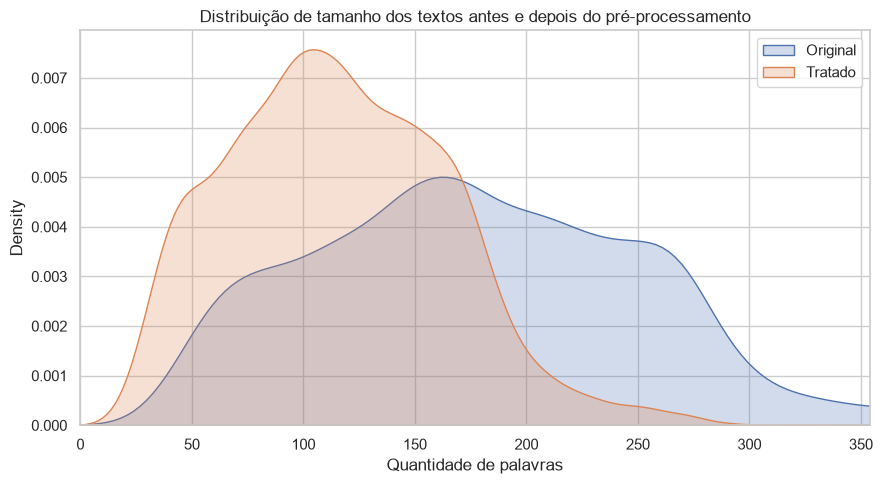

In [14]:
work_df["original_words"] = work_df["text_original"].str.split().str.len()
work_df["clean_words"] = work_df["text_clean"].str.split().str.len()

length_summary = work_df[["original_words", "clean_words"]].describe().round(2)
display(length_summary)

reduction = 1 - work_df["clean_words"].sum() / work_df["original_words"].sum()
print(f"Redução total de tokens após o pré-processamento: {reduction:.1%}")

fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(data=work_df, x="original_words", label="Original", fill=True, alpha=0.25, ax=ax)
sns.kdeplot(data=work_df, x="clean_words", label="Tratado", fill=True, alpha=0.25, ax=ax)
ax.set_xlim(0, work_df["original_words"].quantile(0.98))
ax.set_title("Distribuição de tamanho dos textos antes e depois do pré-processamento")
ax.set_xlabel("Quantidade de palavras")
ax.legend()
plt.tight_layout()
length_plot_path = FIGURE_DIR / "text_length_before_after.png"
fig.savefig(length_plot_path, dpi=140, bbox_inches="tight")
plt.show()

**Leitura.** O pré-processamento remove cerca de 40% dos tokens sem alterar a
forma da distribuição — o que era esperado, já que a maior parte do que sai são
stopwords e pontuação. A cauda longa permanece, confirmando que continua havendo
documentos substanciais depois da limpeza.

### 10.2 Termos mais frequentes e wordclouds

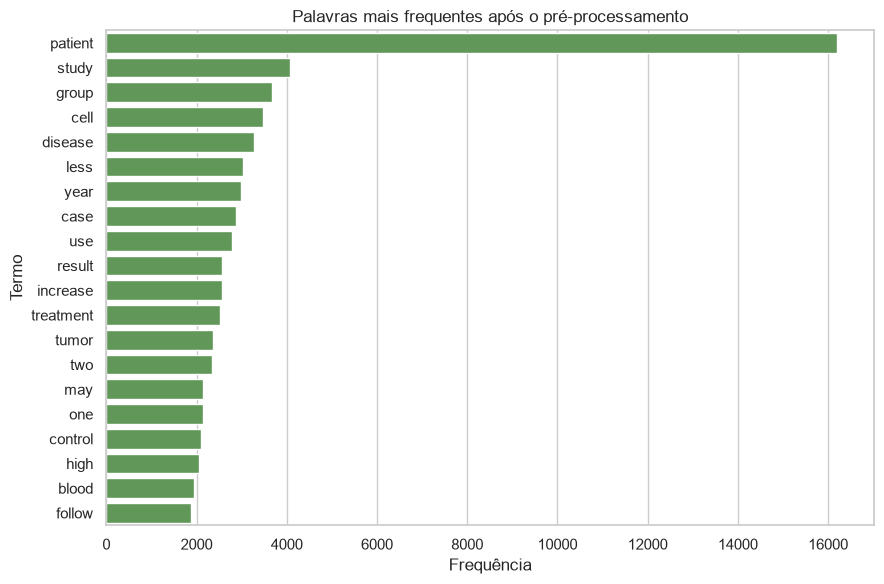

,termo,frequencia
0,patient,16207
1,study,4064
2,group,3679
3,cell,3474
4,disease,3276
5,less,3018
6,year,2976
7,case,2869
8,use,2791
9,result,2569


In [15]:
top_terms = plot_top_terms(
    work_df["text_clean"],
    "Palavras mais frequentes após o pré-processamento",
    FIGURE_DIR / "top_terms_overall.png",
)
display(top_terms)

,classe,termo,frequencia
0,cardiovascular diseases,patient,3762
1,cardiovascular diseases,group,1168
2,cardiovascular diseases,less,1104
3,cardiovascular diseases,pressure,1052
4,cardiovascular diseases,coronary,1008
5,cardiovascular diseases,study,987
6,cardiovascular diseases,artery,932
7,cardiovascular diseases,blood,929
8,cardiovascular diseases,ventricular,832
9,cardiovascular diseases,disease,821


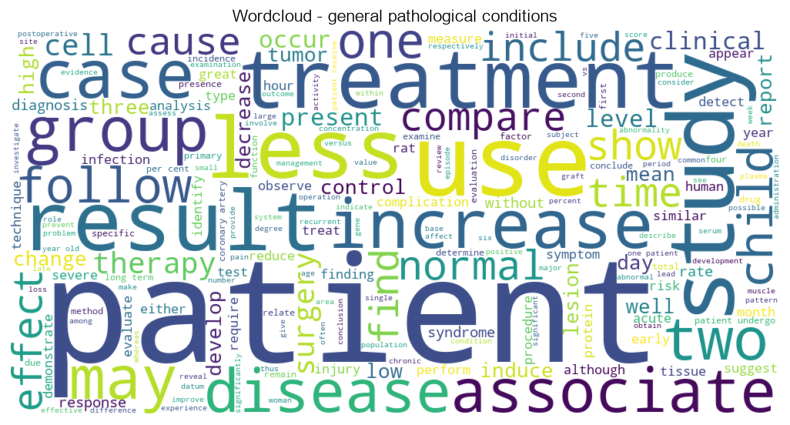

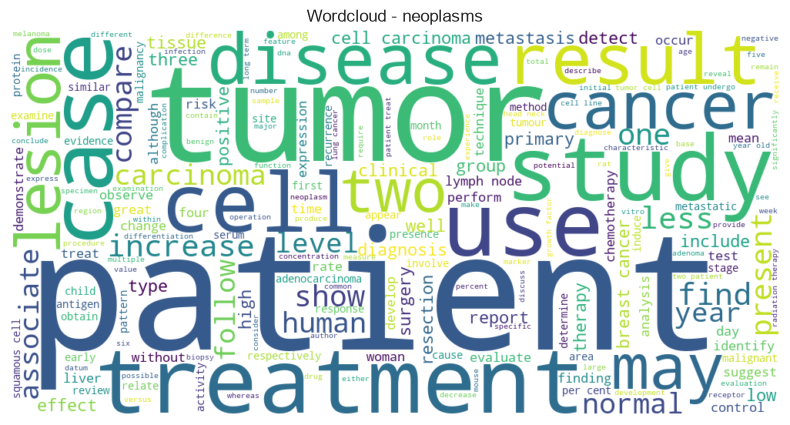

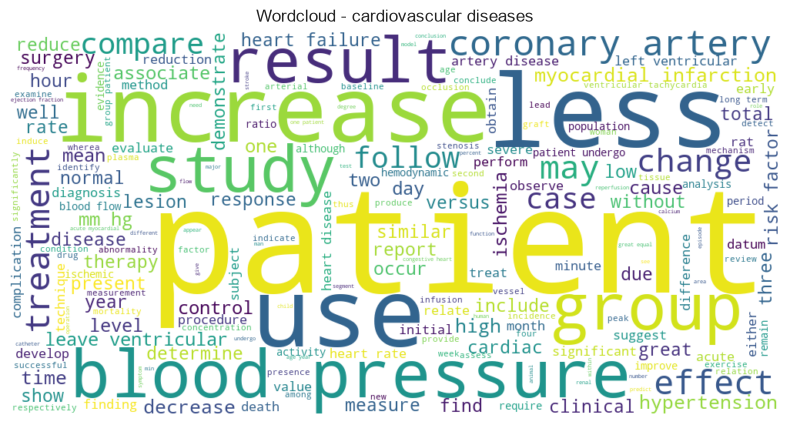

In [16]:
top_terms_by_class = []
for class_name, class_data in work_df.groupby(TARGET_COLUMN):
    counter = Counter(" ".join(class_data["text_clean"].dropna()).split())
    for term, frequency in counter.most_common(10):
        top_terms_by_class.append({"classe": class_name, "termo": term, "frequencia": frequency})

top_terms_by_class = pd.DataFrame(top_terms_by_class)
display(top_terms_by_class.head(30))

for class_name in work_df[TARGET_COLUMN].value_counts().head(3).index:
    class_slug = re.sub(r"[^a-z0-9]+", "_", class_name.lower()).strip("_")
    generate_wordcloud(
        work_df.loc[work_df[TARGET_COLUMN] == class_name, "text_clean"],
        f"Wordcloud - {class_name}",
        FIGURE_DIR / f"wordcloud_{class_slug}.png",
    )

**Leitura.** As listas de termos mais frequentes por classe são dominadas por
vocabulário médico genérico — `patient`, `study`, `case`, `treatment` — que
aparece em todas as classes. Frequência bruta, sozinha, discrimina pouco. A
seção 10.4 corrige isso medindo distintividade em vez de frequência.

### 10.3 Vocabulário: tamanho, cauda e cobertura

Esta é a análise que conecta a EDA diretamente às escolhas de vetorização. Se o
vocabulário tem cauda muito longa, um `max_features` baixo não perde tanta
informação quanto parece — e é isso que precisamos verificar, já que o pipeline
de produção usa `max_features=5000`.

,metrica,valor
0,Tokens totais,"693,314"
1,Vocabulário (tokens únicos),"23,710"
2,Type-token ratio,0.0342
3,Hapax legomena (frequência 1),"6,801 (28.7%)"
4,Tokens por documento (mediana),113


,top_n_termos,cobertura_do_corpus
0,1000,0.6450
1,3000,0.8395
2,5000,0.9037
3,10000,0.9629
4,20000,0.9946


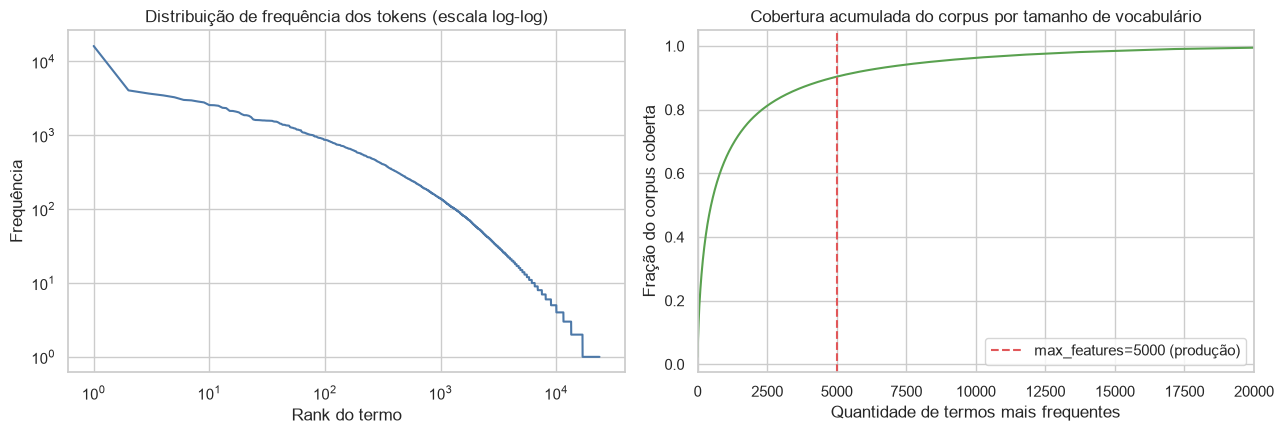

In [17]:
vocabulary_stats, ranked_tokens = summarize_vocabulary(work_df["text_clean"])
display(vocabulary_stats)

cumulative_coverage = ranked_tokens.cumsum() / ranked_tokens.sum()
coverage_rows = [
    {"top_n_termos": k, "cobertura_do_corpus": round(float(cumulative_coverage.iloc[k - 1]), 4)}
    for k in [1000, 3000, 5000, 10000, 20000]
    if k <= len(ranked_tokens)
]
coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].loglog(range(1, len(ranked_tokens) + 1), ranked_tokens.values, color="#4C78A8")
axes[0].set_title("Distribuição de frequência dos tokens (escala log-log)")
axes[0].set_xlabel("Rank do termo")
axes[0].set_ylabel("Frequência")

axes[1].plot(range(1, len(cumulative_coverage) + 1), cumulative_coverage.values, color="#59A14F")
axes[1].axvline(5000, color="#E15759", linestyle="--", label="max_features=5000 (produção)")
axes[1].set_xlim(0, min(20000, len(cumulative_coverage)))
axes[1].set_title("Cobertura acumulada do corpus por tamanho de vocabulário")
axes[1].set_xlabel("Quantidade de termos mais frequentes")
axes[1].set_ylabel("Fração do corpus coberta")
axes[1].legend()
plt.tight_layout()
vocabulary_plot_path = FIGURE_DIR / "vocabulary_coverage.png"
fig.savefig(vocabulary_plot_path, dpi=140, bbox_inches="tight")
plt.show()

**Leitura — e uma justificativa empírica para o pipeline.** O vocabulário segue
uma lei de Zipf clássica, com cerca de **28% de hapax legomena** (termos que
aparecem uma única vez). Essa cauda é quase toda ruído: erros de digitação,
siglas raras e números.

O ponto prático: os **5.000 termos mais frequentes cobrem cerca de 90% de todas
as ocorrências do corpus**. Isso valida empiricamente o `max_features=5000`
usado no pipeline de produção — dobrar o vocabulário para 10.000 adicionaria
apenas ~6 pontos de cobertura, quase todos em termos de baixíssima frequência
que tendem a atrapalhar mais do que ajudar em modelos lineares.

### 10.4 Termos distintivos por classe

Em vez de frequência bruta, medimos **lift**: o quanto um termo é mais frequente
dentro da classe do que no corpus como um todo. É o que revela o vocabulário
que realmente separa as classes.

In [18]:
distinctive_terms = distinctive_terms_by_class(work_df, "text_clean", TARGET_COLUMN)
display(distinctive_terms)

,classe,termo,freq_na_classe,lift
0,cardiovascular diseases,chd,36,4.24
1,cardiovascular diseases,doxazosin,51,4.24
2,cardiovascular diseases,sestamibi,26,4.24
3,cardiovascular diseases,chf,44,4.15
4,cardiovascular diseases,reinjection,34,4.12
5,cardiovascular diseases,dahl,30,4.10
6,cardiovascular diseases,atenolol,33,4.00
7,cardiovascular diseases,enalapril,42,3.96
8,digestive system diseases,dissolution,30,9.69
9,digestive system diseases,capd,33,9.41


**Leitura.** Agora o sinal aparece com clareza clínica: termos como
`spasticity`, `migraine` e `aphasia` marcam `nervous system diseases`;
`mammography` e `psa` marcam `neoplasms`; `atenolol` e `enalapril` marcam
`cardiovascular diseases`.

Repare no contraste com `general pathological conditions`: os termos com maior
lift dessa classe têm valores bem menores e são muito mais heterogêneos. Ela
não tem vocabulário próprio — mais uma evidência independente, agora lexical,
de que ela não é uma categoria semanticamente coesa.

### 10.5 Bigramas: expressões clínicas compostas

Termos isolados perdem expressões que só fazem sentido juntas. Este corte mostra
o que a escolha de `ngram_range=(1, 2)` no pipeline captura.

In [19]:
bigram_vectorizer = TfidfVectorizer(ngram_range=(2, 2), min_df=5, max_features=2000)
bigram_matrix = bigram_vectorizer.fit_transform(work_df["text_clean"])
bigram_weights = np.asarray(bigram_matrix.sum(axis=0)).ravel()

top_bigrams = (
    pd.DataFrame({"bigrama": bigram_vectorizer.get_feature_names_out(), "peso_tfidf": bigram_weights})
    .sort_values("peso_tfidf", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
display(top_bigrams)

,bigrama,peso_tfidf
0,year old,76.627799
1,blood pressure,72.217549
2,long term,71.691946
3,less 05,64.041058
4,coronary artery,63.130676
5,per cent,62.042131
6,patient undergo,61.840495
7,case report,58.601097
8,report case,56.614394
9,two patient,51.693256


**Leitura.** Os bigramas de maior peso são entidades clínicas reais —
`blood pressure`, `coronary artery`, `myocardial infarction`, `breast cancer`,
`magnetic resonance`. São exatamente os casos em que a palavra isolada perde
sentido: `artery` sozinho é ambíguo, `coronary artery` não é.

Isso justifica manter `ngram_range=(1, 2)` na vetorização, ainda que o ganho
medido em métrica seja modesto.

### 10.6 As classes são lexicalmente separáveis?

Este é o teste que fecha o argumento da seção 7, agora por um caminho
independente. Representamos cada classe pelo seu **centroide TF-IDF** e medimos
a similaridade do cosseno entre eles. Classes bem separadas teriam centroides
distantes.

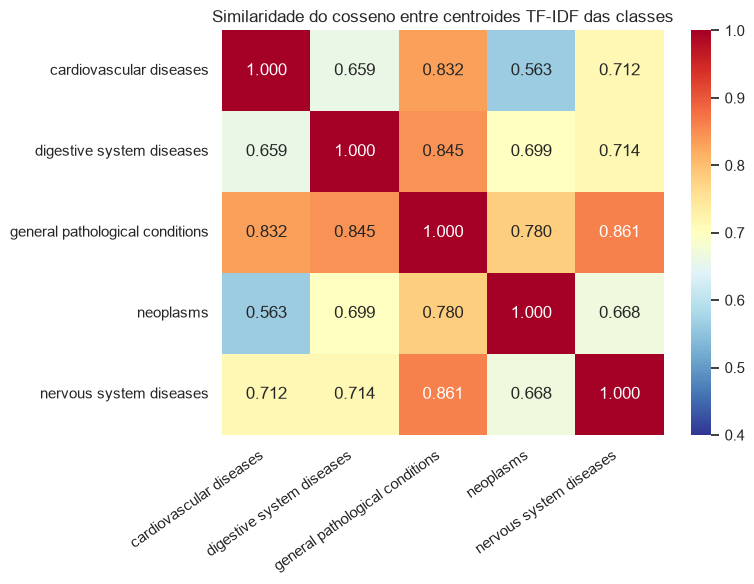

Similaridade média entre classes distintas: 0.733
Maior similaridade entre duas classes distintas: 0.861
Similaridade média de 'general pathological conditions' com as demais: 0.830


In [20]:
centroid_vectorizer = TfidfVectorizer(max_features=5000, min_df=2)
centroid_matrix = centroid_vectorizer.fit_transform(work_df["text_clean"])
class_names = sorted(work_df[TARGET_COLUMN].unique())

centroids = np.vstack([
    np.asarray(centroid_matrix[(work_df[TARGET_COLUMN] == class_name).values].mean(axis=0)).ravel()
    for class_name in class_names
])
normalized = centroids / np.linalg.norm(centroids, axis=1, keepdims=True)
similarity = normalized @ normalized.T
similarity_df = pd.DataFrame(similarity.round(3), index=class_names, columns=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(similarity_df, annot=True, fmt=".3f", cmap="RdYlBu_r", vmin=0.4, vmax=1.0, ax=ax)
ax.set_title("Similaridade do cosseno entre centroides TF-IDF das classes")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
similarity_plot_path = FIGURE_DIR / "class_centroid_similarity.png"
fig.savefig(similarity_plot_path, dpi=140, bbox_inches="tight")
plt.show()

off_diagonal = similarity[~np.eye(len(class_names), dtype=bool)]
print(f"Similaridade média entre classes distintas: {off_diagonal.mean():.3f}")
print(f"Maior similaridade entre duas classes distintas: {off_diagonal.max():.3f}")

gpc_index = class_names.index("general pathological conditions")
gpc_similarities = np.delete(similarity[gpc_index], gpc_index)
print(f"Similaridade média de 'general pathological conditions' com as demais: {gpc_similarities.mean():.3f}")

**Leitura.** A similaridade média entre centroides de classes **distintas** é de
cerca de **0,73** — muito alta para um problema que se supõe separável. Para
comparação, classes realmente disjuntas ficariam bem abaixo de 0,5.

E `general pathological conditions` é a classe mais próxima de todas as outras.
Chegamos à mesma conclusão da seção 7.2 por um caminho completamente
independente: lá pela estrutura dos rótulos, aqui pelo conteúdo lexical. As
classes se sobrepõem porque os textos se sobrepõem.

### 10.7 Os splits oficiais são comparáveis?

Antes de confiar em qualquer métrica de teste, vale confirmar que treino e teste
oficiais têm a mesma distribuição. Divergência aqui invalidaria comparações.

In [21]:
split_distribution = (
    pd.crosstab(df[TARGET_COLUMN], df["source_split"], normalize="columns").round(4).reset_index()
)
split_distribution["diferenca_pp"] = (
    (split_distribution["kaggle_test"] - split_distribution["kaggle_train"]) * 100
).round(2)
print("Proporção de cada classe por split oficial:")
display(split_distribution)

length_by_split = df.groupby("source_split")["text_length_words"].describe().round(1)
print("Tamanho dos textos por split oficial:")
display(length_by_split[["count", "mean", "50%", "max"]])

Proporção de cada classe por split oficial:


source_split,condition_name,kaggle_test,kaggle_train,diferenca_pp
0,cardiovascular diseases,0.2112,0.2113,-0.01
1,digestive system diseases,0.1035,0.1035,0.00
2,general pathological conditions,0.3328,0.3328,0.00
3,neoplasms,0.2192,0.2190,0.02
4,nervous system diseases,0.1333,0.1333,0.00


Tamanho dos textos por split oficial:


,count,mean,50%,max
source_split,,,,
kaggle_test,2888.0,181.1,179.0,528.0
kaggle_train,11550.0,179.6,175.0,596.0


**Leitura.** Os splits são praticamente idênticos: a maior divergência de
proporção entre classes é de **0,02 ponto percentual**, e o tamanho médio dos
textos difere em menos de 2 palavras. O split oficial foi estratificado com
cuidado.

Isso é uma boa notícia com uma ressalva importante: não há *drift* de
distribuição entre treino e teste, então qualquer queda de desempenho no teste
não vem daí — vem da ambiguidade de rótulo documentada na seção 7.

### 10.8 Comprimento dos textos por classe

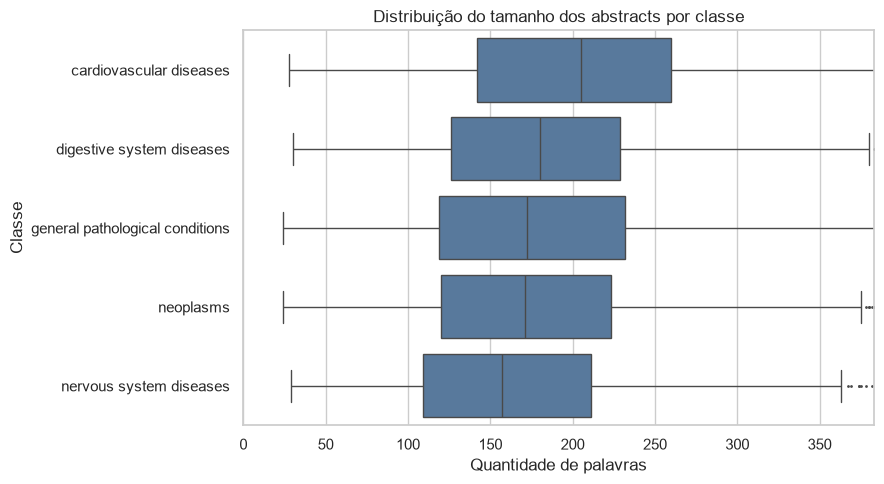

,count,mean,50%,max
condition_name,,,,
cardiovascular diseases,3051.0,199.9,205.0,578.0
digestive system diseases,1494.0,179.5,180.0,417.0
general pathological conditions,4805.0,177.7,172.0,528.0
neoplasms,3163.0,174.9,171.0,528.0
nervous system diseases,1925.0,162.5,157.0,596.0


In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
order = df.groupby(TARGET_COLUMN)["text_length_words"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="text_length_words", y=TARGET_COLUMN, order=order, ax=ax, color="#4C78A8", fliersize=1)
ax.set_xlim(0, df["text_length_words"].quantile(0.99))
ax.set_title("Distribuição do tamanho dos abstracts por classe")
ax.set_xlabel("Quantidade de palavras")
ax.set_ylabel("Classe")
plt.tight_layout()
length_by_class_path = FIGURE_DIR / "text_length_by_class.png"
fig.savefig(length_by_class_path, dpi=140, bbox_inches="tight")
plt.show()

display(df.groupby(TARGET_COLUMN)["text_length_words"].describe().round(1)[["count", "mean", "50%", "max"]])

**Leitura.** As distribuições se sobrepõem quase completamente. `cardiovascular
diseases` tem a mediana mais alta (~205 palavras) e `nervous system diseases` a
mais baixa (~159), mas a diferença é pequena diante da dispersão.

Conclusão prática: **o comprimento do texto não é uma feature discriminativa**
neste problema, e não vale a pena engenheirá-la.

## 11. Principais achados

In [23]:
minority_class = class_distribution.sort_values("registros").iloc[0]["classe"]
largest_class = class_distribution.sort_values("registros", ascending=False).iloc[0]["classe"]

findings = [
    f"A base consolidada possui {len(df):,} linhas, {len(label_sets_by_text):,} abstracts únicos e {df[TARGET_COLUMN].nunique()} classes.",
    f"A maior classe é '{largest_class}' e a menor é '{minority_class}'; o desbalanceamento é moderado (~3x) e pede macro-F1 em vez de acurácia.",
    f"ACHADO PRINCIPAL: o corpus é multirrótulo achatado — {multilabel_share:.0%} dos abstracts têm mais de um rótulo válido, e o par (texto, rótulo) nunca se repete.",
    f"Cerca de {len(overlap_keys) / len(test_multilabel):.0%} dos abstracts do teste oficial também aparecem no treino; todas as ocorrências desses textos são removidas somente do treino (ver seção 7.3).",
    "'general pathological conditions' é transversal, não disjunta: ~50% dos seus abstracts têm outro rótulo, e ela é a classe mais próxima de todas as outras no espaço TF-IDF.",
    f"Os {5000} termos mais frequentes cobrem ~{cumulative_coverage.iloc[4999]:.0%} do corpus, o que valida empiricamente o max_features=5000 do pipeline de produção.",
    "Bigramas capturam entidades clínicas reais (blood pressure, coronary artery), justificando ngram_range=(1, 2).",
    "Os splits oficiais de treino e teste são estatisticamente equivalentes: não há drift de distribuição a corrigir.",
    "O comprimento do texto não discrimina classes e não deve ser usado como feature.",
    "Números foram preservados no pré-processamento por poderem carregar informação clínica relevante.",
    "A análise usa abstracts médicos públicos como proxy acadêmico; não são dados operacionais de hospital nem validação clínica.",
]

for item in findings:
    print(f"- {item}")

- A base consolidada possui 14,438 linhas, 11,227 abstracts únicos e 5 classes.
- A maior classe é 'general pathological conditions' e a menor é 'digestive system diseases'; o desbalanceamento é moderado (~3x) e pede macro-F1 em vez de acurácia.
- ACHADO PRINCIPAL: o corpus é multirrótulo achatado — 26% dos abstracts têm mais de um rótulo válido, e o par (texto, rótulo) nunca se repete.
- Cerca de 36% dos abstracts do teste oficial também aparecem no treino; todas as ocorrências desses textos são removidas somente do treino (ver seção 7.3).
- 'general pathological conditions' é transversal, não disjunta: ~50% dos seus abstracts têm outro rótulo, e ela é a classe mais próxima de todas as outras no espaço TF-IDF.
- Os 5000 termos mais frequentes cobrem ~90% do corpus, o que valida empiricamente o max_features=5000 do pipeline de produção.
- Bigramas capturam entidades clínicas reais (blood pressure, coronary artery), justificando ngram_range=(1, 2).
- Os splits oficiais de treino e teste

### Próximos passos

1. Gerar os splits multilabel seguros com `make dataset`.
2. Treinar cinco classificadores binários com `OneVsRestClassifier` e TF-IDF.
3. Selecionar hiperparâmetros por F1-macro multilabel usando apenas treino/validação.
4. Avaliar no teste preservado com F1 macro/micro, subset accuracy, Hamming loss e recall por classe.
5. Registrar no MLflow a política de deduplicação, as contagens e o hash/configuração do experimento.

## 12. Relatório de EDA em HTML

Consolida os achados desta análise num relatório navegável, salvo em
`reports/eda_nlp_hospital.html`.

In [24]:
def image_tag(path: Path, alt: str) -> str:
    """Retorna uma tag HTML de imagem quando o arquivo existe."""
    if not path.exists():
        return f"<p><em>Figura não encontrada: {escape(str(path))}</em></p>"
    relative = path.relative_to(REPORT_DIR).as_posix()
    return f'<figure><img src="{escape(relative)}" alt="{escape(alt)}"><figcaption>{escape(alt)}</figcaption></figure>'


library_versions = pd.DataFrame(
    [
        {"biblioteca": "python", "versao": "3.11"},
        {"biblioteca": "pandas", "versao": pd.__version__},
        {"biblioteca": "numpy", "versao": np.__version__},
        {"biblioteca": "scikit-learn", "versao": sklearn.__version__},
        {"biblioteca": "matplotlib", "versao": matplotlib.__version__},
        {"biblioteca": "seaborn", "versao": sns.__version__},
        {"biblioteca": "nltk", "versao": nltk.__version__},
        {"biblioteca": "spaCy", "versao": spacy.__version__},
        {"biblioteca": "spaCy model", "versao": spacy_model_used},
    ]
)

wordcloud_html = "\n".join(
    image_tag(path, f"Wordcloud - {path.stem.replace('wordcloud_', '').replace('_', ' ')}")
    for path in sorted(FIGURE_DIR.glob("wordcloud_*.png"))
)

html = f"""
<!doctype html>
<html lang="pt-BR">
<head>
  <meta charset="utf-8">
  <title>Relatório de EDA — Abstracts Médicos</title>
  <style>
    body {{ font-family: Arial, sans-serif; line-height: 1.5; margin: 40px; color: #222; }}
    h1, h2 {{ color: #1f4e79; }}
    table {{ border-collapse: collapse; width: 100%; margin: 16px 0; }}
    th, td {{ border: 1px solid #ddd; padding: 8px; text-align: left; }}
    th {{ background: #f2f5f7; }}
    img {{ max-width: 100%; height: auto; border: 1px solid #ddd; }}
    figure {{ margin: 20px 0; }}
    figcaption {{ font-size: 0.9em; color: #555; }}
    .note {{ background: #fff8e1; padding: 12px; border-left: 4px solid #d39e00; }}
    .key {{ background: #e8f4fd; padding: 12px; border-left: 4px solid #1f4e79; }}
  </style>
</head>
<body>
  <h1>Relatório de Análise Exploratória — Classificação de Abstracts Médicos</h1>
  <p class="note">Relatório exploratório. O dataset é composto por abstracts médicos públicos e deve ser tratado como proxy acadêmico, não como validação clínica.</p>

  <h2>1. Contexto do dataset</h2>
  <p>Origem: Medical Abstracts TC Corpus (Kaggle). A base contém abstracts médicos rotulados por condição.</p>
  {class_distribution.to_html(index=False)}
  {image_tag(class_plot_path, "Distribuição das classes")}

  <h2>2. Problema de classificação</h2>
  <p>A tarefa é classificação multilabel: um mesmo abstract pode ser válido sob mais de uma condição (seção 1). A seção 4 deste relatório mede o tamanho desse efeito no corpus.</p>

  <h2>3. Qualidade dos dados</h2>
  {sanity_report.to_html(index=False)}
  <p>A base não tem nulos, vazios ou classes órfãs. A anomalia relevante está nas duplicidades: milhares de textos repetidos, mas <strong>zero</strong> pares (texto, classe) repetidos.</p>

  <h2>4. Achado crítico: corpus multirrótulo achatado</h2>
  <div class="key">
    <p>O corpus é originalmente multirrótulo e foi distribuído em formato achatado — uma linha por par (abstract, condição).</p>
    <ul>
      <li><strong>{multilabel_share:.0%}</strong> dos abstracts únicos têm mais de um rótulo válido.</li>
      <li><strong>{len(overlap_keys) / len(test_multilabel):.0%}</strong> dos abstracts do teste oficial também aparecem no treino; todas as ocorrências desses textos foram removidas somente do treino.</li>
    </ul>
  </div>
  {multilabel_summary.to_html(index=False)}
  {cooccurrence_df.head(10).to_html(index=False)}
  {per_label_multilabel.to_html(index=False)}

  <h2>5. Preparação dos dados</h2>
  <p>Normalização unicode, minúsculas, remoção de pontuação, remoção de stopwords via NLTK e lematização com spaCy. Números foram preservados por poderem carregar informação clínica.</p>
  {length_summary.to_html()}
  {image_tag(length_plot_path, "Distribuição de tamanho antes e depois do pré-processamento")}

  <h2>6. Gráficos e principais insights textuais</h2>
  {image_tag(FIGURE_DIR / "top_terms_overall.png", "Palavras mais frequentes após o pré-processamento")}
  {top_terms.head(20).to_html(index=False)}
  {wordcloud_html}

  <h2>7. Vocabulário e implicações para a vetorização</h2>
  {vocabulary_stats.to_html(index=False)}
  {coverage_df.to_html(index=False)}
  {image_tag(vocabulary_plot_path, "Distribuição de frequência e cobertura acumulada do vocabulário")}
  <p>Os 5.000 termos mais frequentes cobrem cerca de {cumulative_coverage.iloc[4999]:.0%} do corpus, validando empiricamente o <code>max_features=5000</code> do pipeline de produção.</p>
  <h3>Termos distintivos por classe (lift)</h3>
  {distinctive_terms.to_html(index=False)}
  <h3>Bigramas de maior peso</h3>
  {top_bigrams.head(15).to_html(index=False)}

  <h2>8. Sobreposição entre classes</h2>
  {image_tag(similarity_plot_path, "Similaridade do cosseno entre centroides TF-IDF das classes")}
  <p>Similaridade média entre classes distintas: <strong>{off_diagonal.mean():.3f}</strong>. As classes não são lexicalmente disjuntas, o que confirma pelo conteúdo o que a seção 4 mostrou pela estrutura dos rótulos.</p>
  {image_tag(length_by_class_path, "Distribuição do tamanho dos abstracts por classe")}

  <h2>9. Comparabilidade dos splits oficiais</h2>
  {split_distribution.to_html(index=False)}
  <p>Treino e teste oficiais são estatisticamente equivalentes; não há drift de distribuição a corrigir.</p>

  <h2>10. Bibliotecas usadas no desenvolvimento</h2>
  {library_versions.to_html(index=False)}

  <h2>11. Privacidade e dados sensíveis</h2>
  <p>O notebook evita exibir textos completos em massa e usa exemplos truncados. Em dados reais de hospital, seriam necessários mascaramento de informações sensíveis, controle de acesso, revisão jurídica e validação clínica antes de qualquer uso operacional.</p>

  <h2>12. Limitações</h2>
  <ul>
    <li>A etapa de pré-processamento textual usa amostra estratificada de {WORKING_SAMPLE_SIZE:,} registros; a análise estrutural usa o corpus completo.</li>
    <li>Dataset em inglês, baseado em abstracts científicos, não em fluxo real de triagem hospitalar.</li>
    <li>O pipeline de produção (fora deste notebook) resolve a ambiguidade documentada aqui treinando um classificador multilabel (<code>OneVsRestClassifier</code>, um binário por categoria) em vez de perseguir um teto de rótulo único.</li>
    <li>Modelagem e avaliação de modelos estão no notebook 02_baseline_modelagem.ipynb.</li>
  </ul>
</body>
</html>
"""

REPORT_PATH.write_text(html, encoding="utf-8")
print(f"Relatório salvo em: {REPORT_PATH}")

Relatório salvo em: C:\Users\jayne_m2ck4ov\Documents\POS MLE\FASE 3\ml3-f3-tech-challenge\reports\eda_nlp_hospital.html
